In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import shutil
import os
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from dateutil.relativedelta import relativedelta

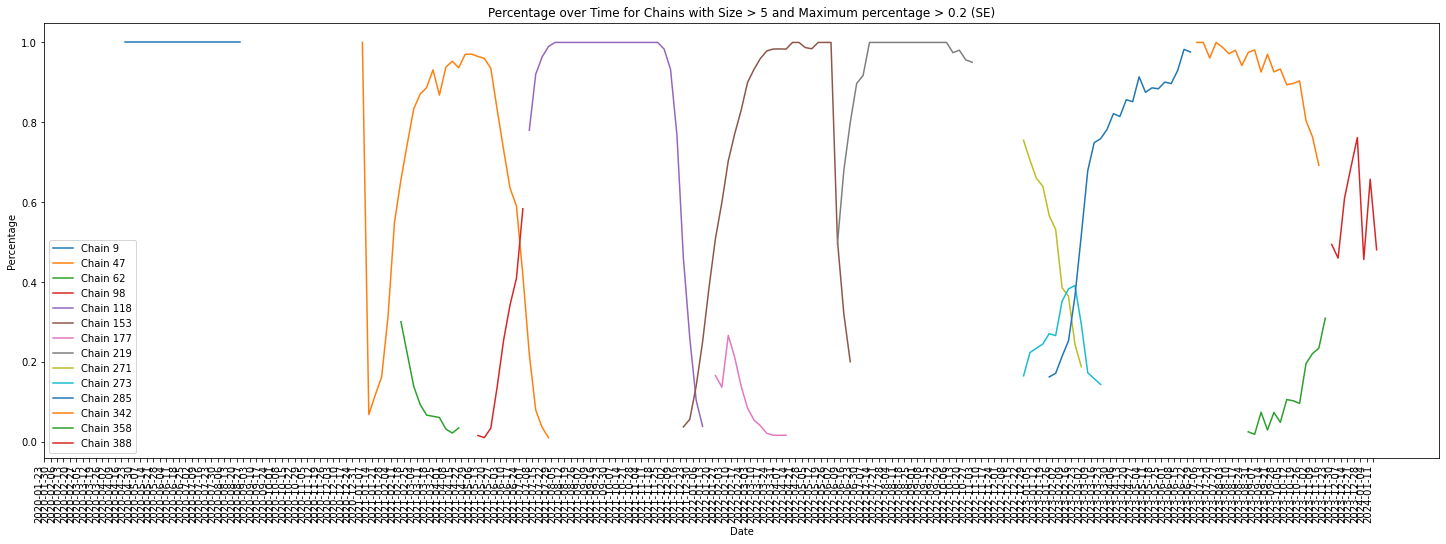

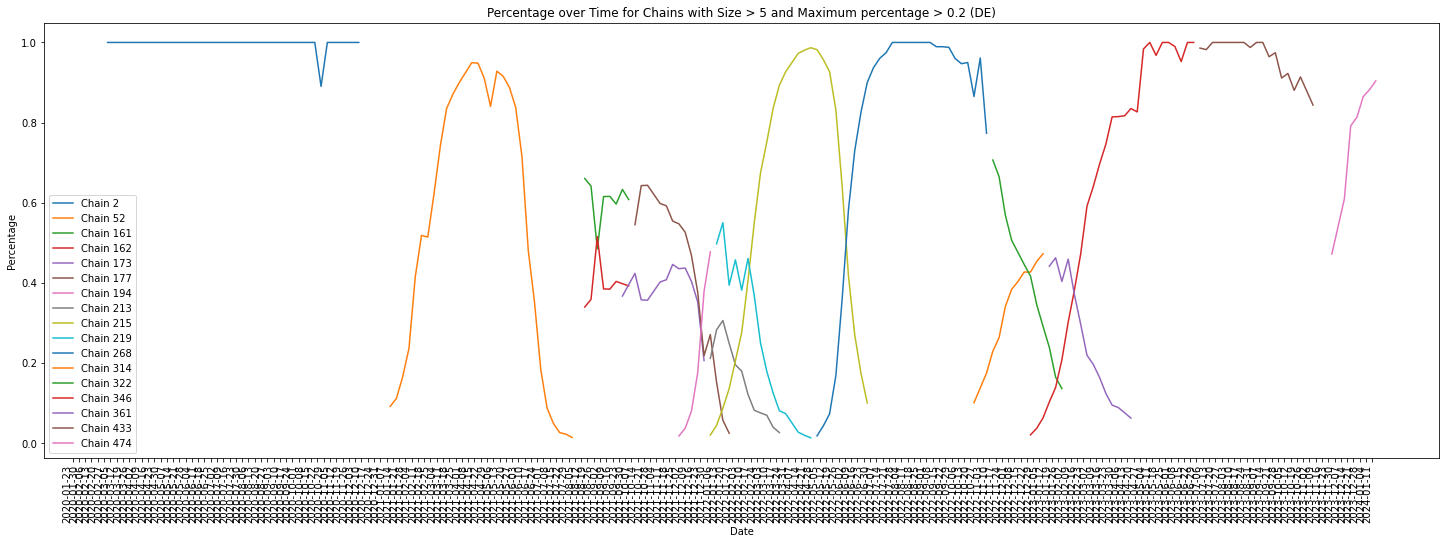

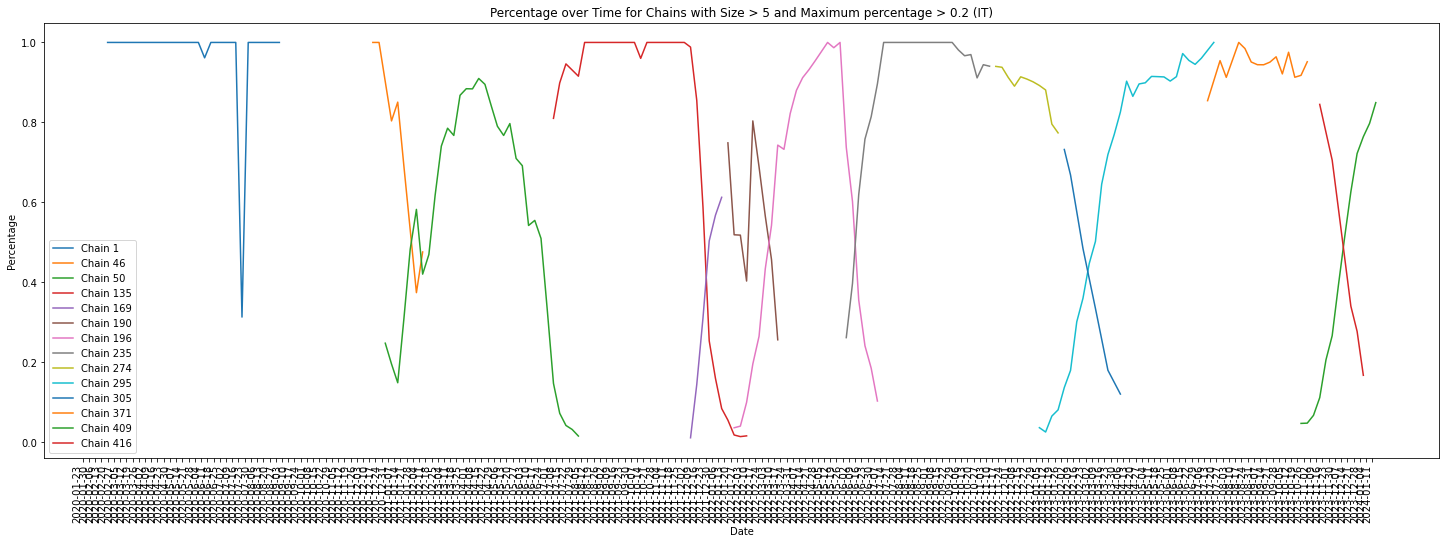

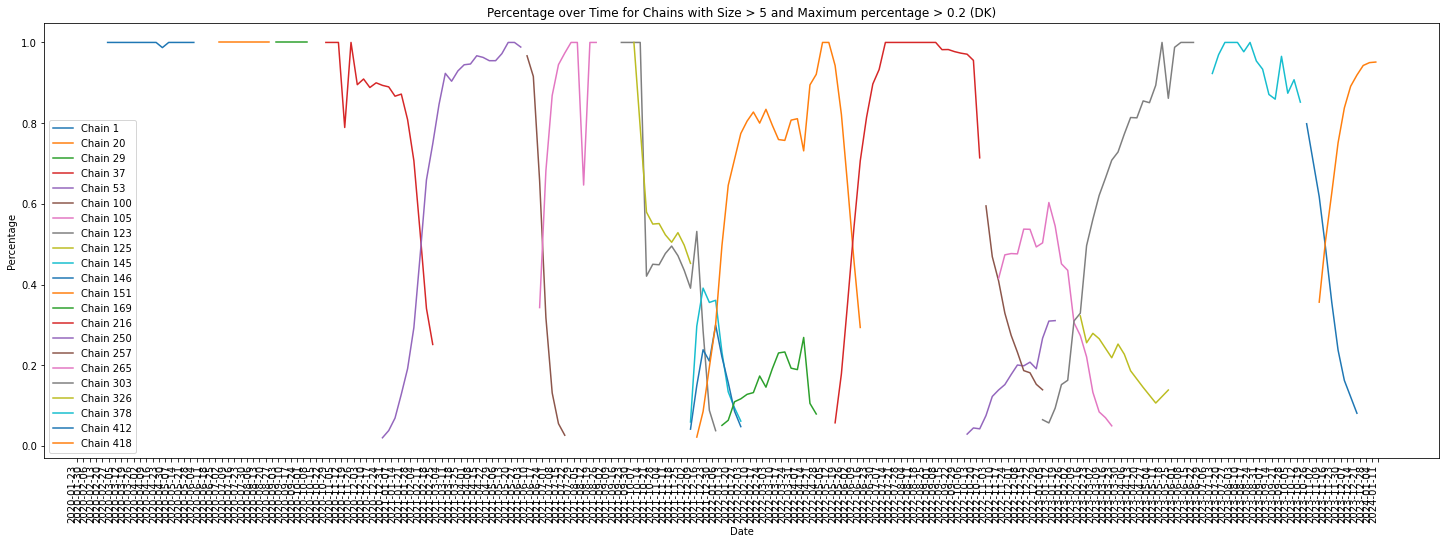

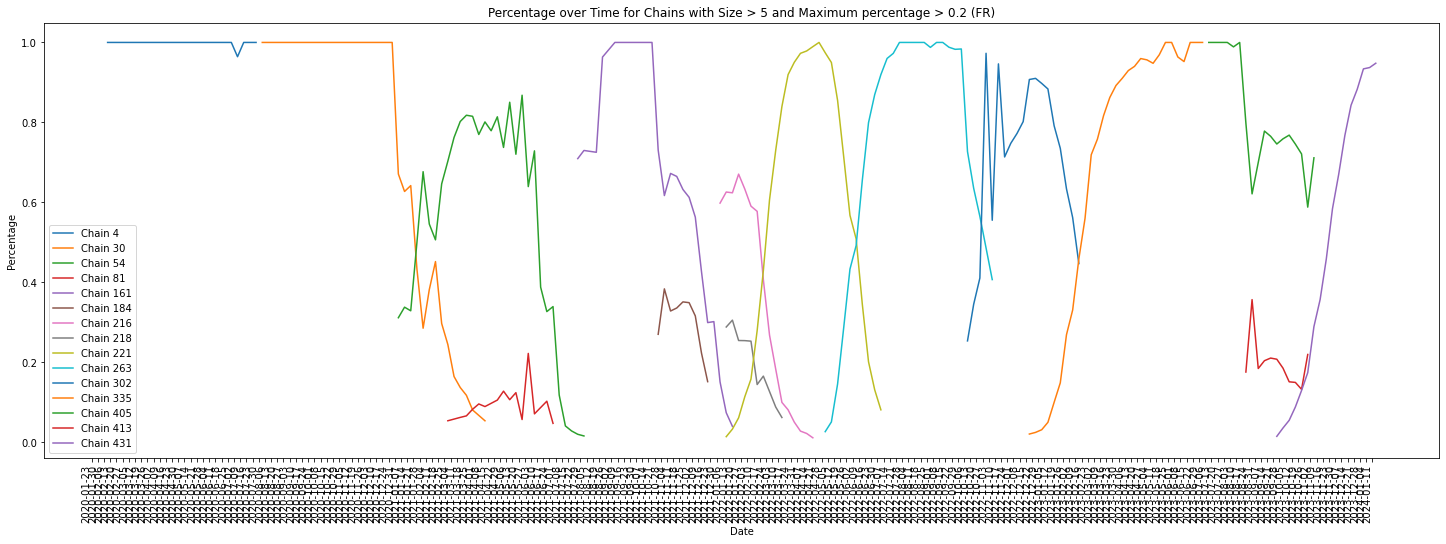

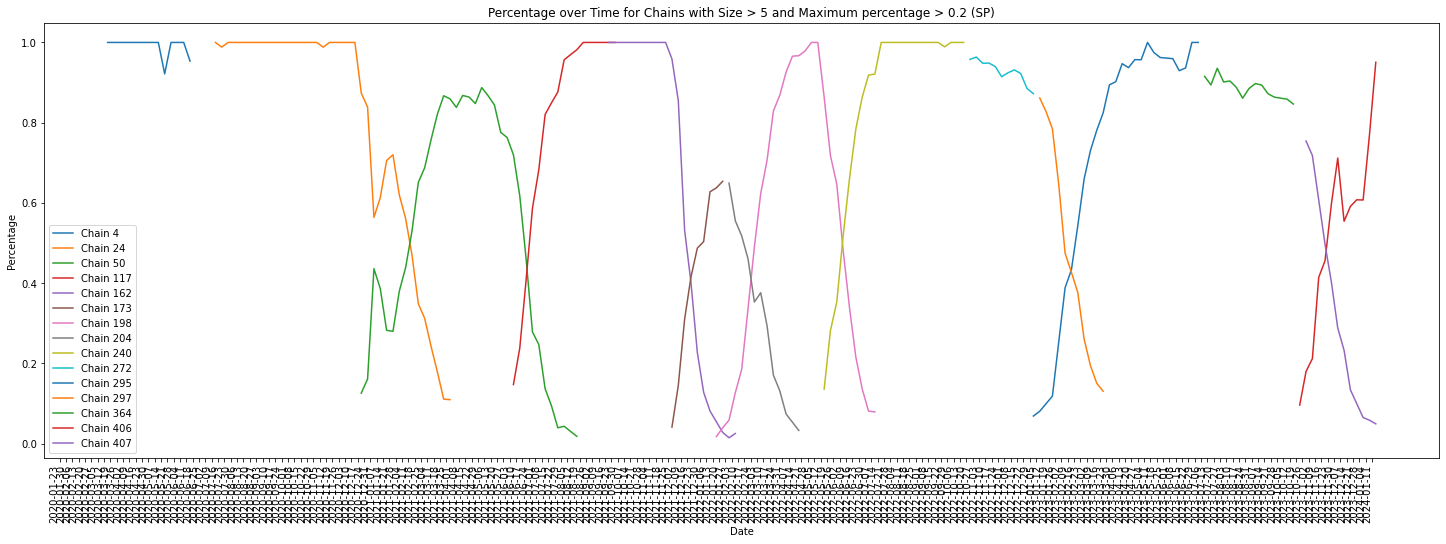

In [4]:
country_list = ['SE', 'DE', 'IT', 'DK', 'FR', 'SP']
clustering_file = 'Covid_cluster.csv'

dfs = {}

#open the file for each of the countries in country_list
for country in country_list:
    #print(country)
    fold_to_open = 'data/2020_' + country
    #print(fold_to_open)
    df_country = pd.read_csv(fold_to_open + '/' + clustering_file)
    df_country['date'] = pd.to_datetime(df_country['date'])
    df_country['country'] = country
    df_country = df_country.sort_values('date')
    dfs[country] = df_country

#find the initial and final date for each country
start_date = min(df['date'].min() for df in dfs.values())
end_date = max(df['date'].max() for df in dfs.values())
#generate weekly dates in the range of dates
week_dates = [start_date + pd.DateOffset(weeks=x) for x in range((end_date - start_date).days // 7 + 1)]
#find the max value of 'pct' for each group of values equal to 'chain'
max_values = df_country.groupby('chain')['pct'].max().reset_index()
#get a plot for each country with raw chains
for country, df_country in dfs.items():
    max_values = df_country.groupby('chain')['pct'].max().reset_index()
    #we filter the max values of 'pct' to satisfy the condition maximum percentage > 0.2
    max_values_filtered = max_values[max_values['pct'] > 0.2]
    #filter to satisfy both the conditions: chain_size > 5 e maximum percentage > 0.2
    df_filtered = df_country[(df_country['chain_size'] > 5) & (df_country['chain'].isin(max_values_filtered['chain']))]

    #group by 'chain' and create a curve for each 'chain'
    grouped_data = df_filtered.groupby('chain')
    fig, ax = plt.subplots(figsize=(25, 8))

    for name, group in grouped_data:
        ax.plot(group['date'], group['pct'], label=f'Chain {name}')
        
    ax.set_xlabel('Date')
    ax.set_ylabel('Percentage')
    ax.legend()
    ax.set_title(f'Percentage over Time for Chains with Size > 5 and Maximum percentage > 0.2 ({country})')
    ax.set_xticks(week_dates)
    ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=90, ha="right") 